# 05 — Clustering per Zona

Fase 1 riset: "Mengelompokkan POI berdasarkan lokasi geografis ... untuk
memudahkan penjadwalan per hari (cluster per zona wilayah Jakarta)".
K-Means by lat/lon -> `zone_id`. Hasil jadi basis scope `time_matrix`
(06_time_matrix.ipynb) -- matrix dihitung hanya antar-venue dalam zone
sama, bukan all-pairs se-Jakarta.

In [1]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import matplotlib.pyplot as plt
import config

In [2]:
df = pd.read_csv("../../data/processed/clustered_venues.csv")
print(f"Total venue: {len(df)}")
print(f"Jumlah zona (k={config.CLUSTER_K}):")
df["zone_id"].value_counts().sort_index()

Total venue: 340
Jumlah zona (k=8):


zone_id
0    28
1    57
2    67
3    30
4    19
5    59
6    51
7    29
Name: count, dtype: int64

## Sebaran geografis per zona

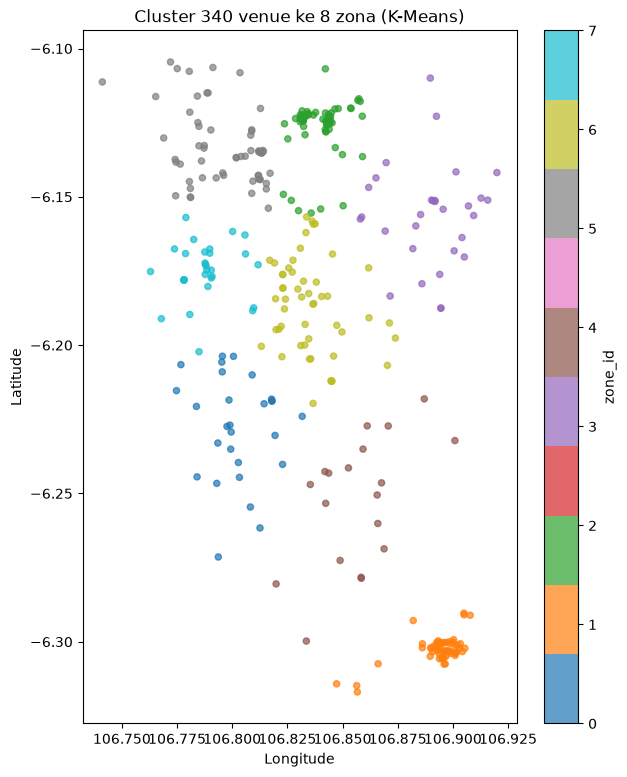

In [3]:
fig, ax = plt.subplots(figsize=(7, 9))
scatter = ax.scatter(df["longitude"], df["latitude"], c=df["zone_id"],
                      cmap="tab10", s=20, alpha=0.7)
ax.set_title(f"Cluster {len(df)} venue ke {config.CLUSTER_K} zona (K-Means)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(scatter, label="zone_id", ticks=range(config.CLUSTER_K))
plt.show()

## Kategori dominan per zona

Sanity check: tiap zona harus punya karakter geografis yang masuk akal
(cth zona pesisir didominasi Beach/Theme Park, zona pusat kota didominasi
Museum/Monument).

In [4]:
for zone in sorted(df["zone_id"].unique()):
    top_cat = df[df["zone_id"] == zone]["venue_category"].value_counts().head(3)
    n = len(df[df["zone_id"] == zone])
    print(f"zone {zone} ({n} venue): {dict(top_cat)}")

zone 0 (28 venue): {'Theme Park': np.int64(6), 'Temple': np.int64(6), 'History Museum': np.int64(4)}
zone 1 (57 venue): {'Museum': np.int64(28), 'History Museum': np.int64(6), 'Science Museum': np.int64(5)}
zone 2 (67 venue): {'Beach': np.int64(22), 'Theme Park': np.int64(19), 'Zoo': np.int64(8)}
zone 3 (30 venue): {'Theme Park': np.int64(10), 'Temple': np.int64(5), 'Beach': np.int64(4)}
zone 4 (19 venue): {'Theme Park': np.int64(5), 'Beach': np.int64(4), 'Temple': np.int64(3)}
zone 5 (59 venue): {'Temple': np.int64(34), 'Beach': np.int64(7), 'History Museum': np.int64(5)}
zone 6 (51 venue): {'History Museum': np.int64(13), 'Temple': np.int64(9), 'Monument / Landmark': np.int64(8)}
zone 7 (29 venue): {'Temple': np.int64(13), 'Theme Park': np.int64(9), 'Art Museum': np.int64(3)}


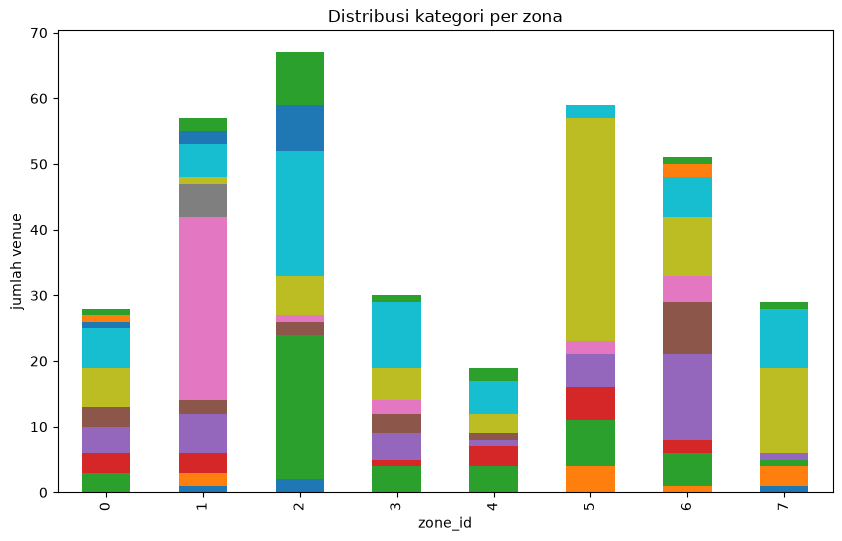

In [5]:
pivot = pd.crosstab(df["zone_id"], df["venue_category"])
pivot.plot(kind="bar", stacked=True, figsize=(10, 6), legend=False)
plt.title("Distribusi kategori per zona")
plt.xlabel("zone_id")
plt.ylabel("jumlah venue")
plt.show()